Experiment - 3 (Singular Value Decomposition)

---

Name : Shruti Hore

PRN : 24070126172

---

Implementing SVD on a single image.

In [7]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import cv2

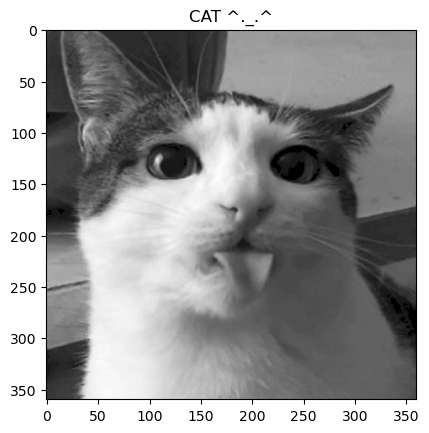

In [8]:
image = cv2.imread('test_cat.png',
                   cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.title('CAT ^._.^')
plt.show()

In [9]:
# define U, S, Vt
U, S, Vt = np.linalg.svd(image, 
                         full_matrices=False)

print('Left Singular Vector (U) Shape   :', U.shape)
print('Diagonal Matrix (Σ) Shape        :', S.shape)
print('Right Singular Vector (Vᵀ) Shape :', Vt.shape)

Left Singular Vector (U) Shape   : (360, 360)
Diagonal Matrix (Σ) Shape        : (360,)
Right Singular Vector (Vᵀ) Shape : (360, 360)


In [10]:
# First and last 10 singular values
S[:10], S[-10:]

(array([40497.89197752, 12006.37680189,  7284.07461331,  4210.78017967,
         3144.93540114,  2738.59937892,  1791.84397953,  1692.9623595 ,
         1414.15879092,  1290.33684826]),
 array([0.74816783, 0.60915404, 0.550812  , 0.49960596, 0.42255608,
        0.36551517, 0.27923866, 0.19124131, 0.13077745, 0.06257808]))

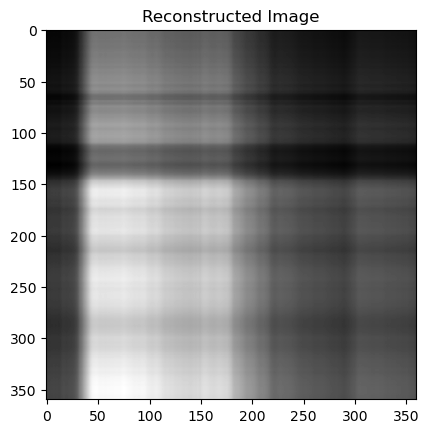

In [11]:
rec_image = np.matrix(U[:,:1] * np.diag(S[:1]) * np.matrix(Vt[:1,:]))
plt.imshow(rec_image, cmap='gray')
plt.title('Reconstructed Image')
plt.show()

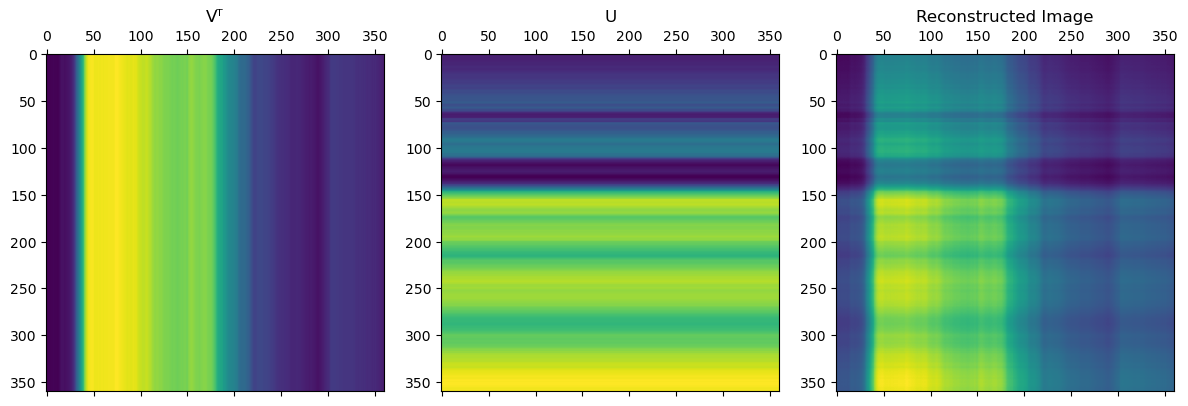

In [12]:
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(131)
ax1.matshow(-np.ones_like(np.matrix(Vt[:1,:])).T * np.matrix(Vt[:1,:]))
ax1.set_title('Vᵀ')

ax2 = fig.add_subplot(132)
ax2.matshow(-(np.ones_like(np.matrix(U[:,:1])) * np.matrix(U[:,:1]).T).T)
ax2.set_title('U')

ax3 = fig.add_subplot(133)
ax3.matshow(rec_image)
ax3.set_title('Reconstructed Image')

plt.tight_layout()
plt.show()

The image is produced from a single outer product of two vectors, forming a rank-1 matrix. In SVD, the full image is reconstructed by summing multiple such rank-1 matrices, and adding more of them improves the approximation.

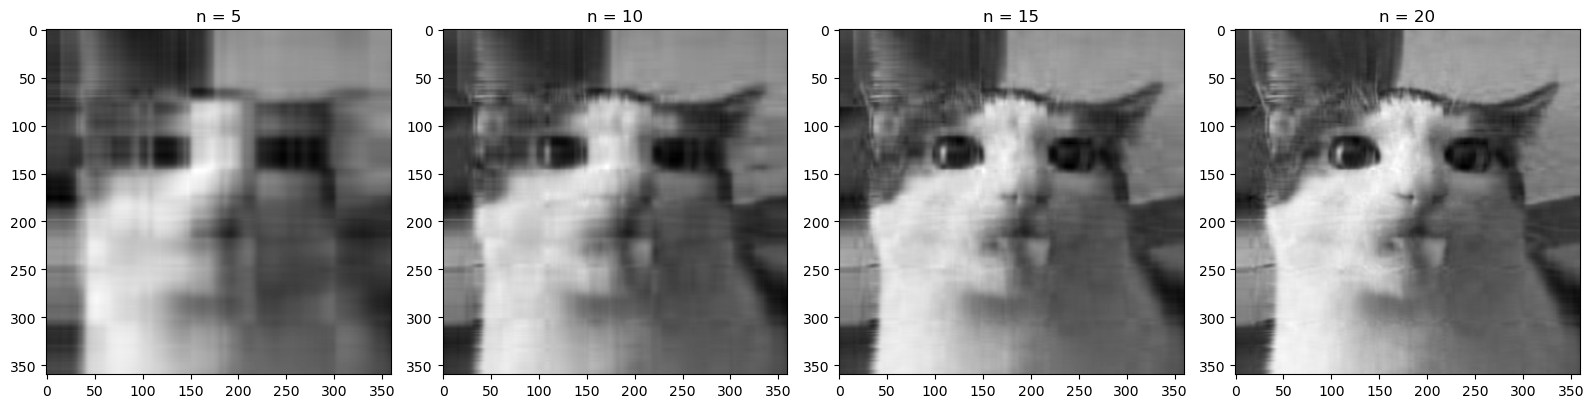

In [13]:
plt.figure(figsize=(16,4))

start, end, step = 5, 24, 5
for i in range(start, end, step):
    plt.subplot(1, (end - start) // step + 1, (i - start) // step + 1)
    rec = np.matrix(U[:, :i]) * np.diag(S[:i]) * np.matrix(Vt[:i, :])
    plt.imshow(rec, cmap='gray')
    plt.title('n = %s' % i)
plt.tight_layout()
plt.show()

In [22]:
k = 20
Uk = U[:, :k]
Sk = np.diag(S[:k])
Vtk = Vt[:k, :]

x_redu = Uk @ Sk
print('Reduced data shape :', x_redu.shape)

Reduced data shape : (360, 20)


As we increase the number of singular values used in the reconstruction, the image is much clearer and we can clearly see the original image within the first 20 singular values

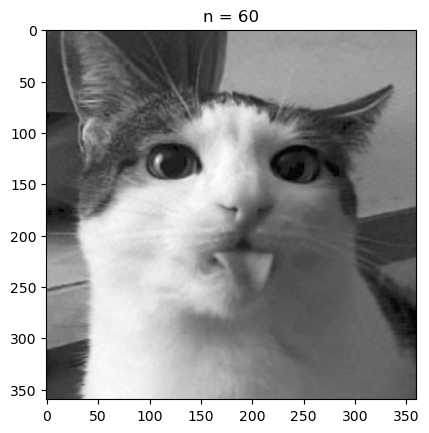

In [14]:
n = 60
reconstructed = np.matrix(U[:, :n]) * np.diag(S[:n]) * np.matrix(Vt[:n, :])
plt.imshow(reconstructed, cmap='gray')
plt.title('n = %s' % n)
plt.show()

With n equal to 60 we are already fairly close to the quality of the original image, but the size of the compressed image is roughly a sixth of the original size.

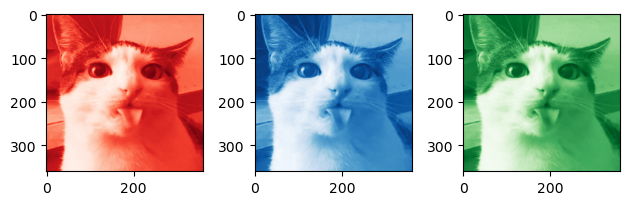

In [15]:
# color images
clr_img = cv2.imread('test_cat.png')
B, G, R = cv2.split(clr_img)

plt.subplot(1, 3, 1)
plt.imshow(R, cmap='Reds_r')

plt.subplot(1, 3, 2)
plt.imshow(B, cmap='Blues_r')

plt.subplot(1, 3, 3)
plt.imshow(G, cmap='Greens_r')

plt.tight_layout()

### SVD on Discrete Noise Image

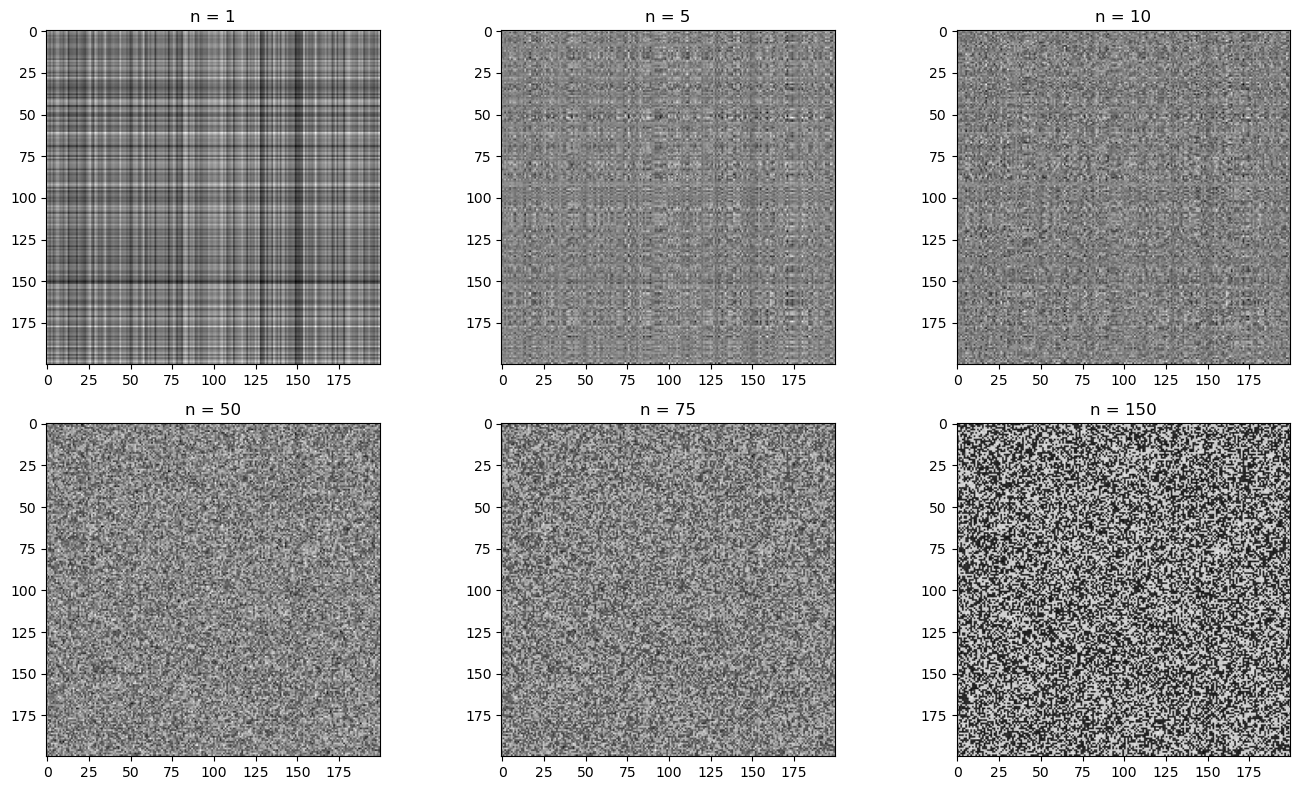

In [17]:
# discrete noise image

noise = np.random.randint(0, 2, size=(200, 200))
Un, Sn, Vtn = np.linalg.svd(noise, full_matrices=False)

comp = [1, 5, 10, 50, 75, 150]

fig = plt.figure(figsize=(14, 8))

for i in range(len(comp)):
    plt.subplot(2, 3, i+1)
    noise_compr = np.matrix(Un[:, :comp[i]]) * np.diag(Sn[:comp[i]]) * np.matrix(Vtn[:comp[i], :])
    plt.imshow(noise_compr, cmap='gray')
    plt.title('n = %s' % comp[i])

plt.tight_layout()
plt.show()

- For small n, the image looks blurry and lacks detail.

- As n increases, the image gradually resembles the original noise.

- Unlike structured images, noise requires many singular values for accurate reconstruction because it lacks dominant low-rank structure.

In [18]:
Sn[:10], Sn[-10:]

(array([100.08173634,  13.7297146 ,  13.51497926,  13.35088463,
         13.28920775,  12.98970031,  12.93663149,  12.78438448,
         12.67150975,  12.48476679]),
 array([0.52922235, 0.42433605, 0.37985284, 0.36294522, 0.32444823,
        0.23696168, 0.17255738, 0.13682958, 0.08746953, 0.03095875]))

- The first singular value (~100) dominates the others (~13).
- It is nearly an order of magnitude larger than the second.
- Most image information is captured by the first component.

### Conclusion
- Singular Value Decomposition (SVD) decomposes an image into a sum of rank-1 matrices.

- The first few singular values capture the most important structural information.

- Structured images (e.g., natural images) can be well-approximated using only a small number of components.

- Random noise images require many components because their singular values decay slowly.

Therefore, SVD is highly effective for image compression when the data has strong underlying structure.